In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import os

# Check current working directory
print("Current folder:", os.getcwd())

# List files in data/immr
try:
    files = os.listdir('data/immr')
    print("Files in data/immr:", files)
except:
    print("data/immr folder not found!")

Current folder: C:\Users\MSI
data/immr folder not found!


In [5]:
files = os.listdir('data/immr')
print("Files in data/immr:", files)

Files in data/immr: ['FlowOpt_IMMR_Complete.xlsx', 'FlowOpt_SriLanka_AHB_Data.xlsx']


In [7]:
# Load IMMR annual totals
df_immr = pd.read_excel(
    'data/immr/FlowOpt_IMMR_Complete.xlsx',
    sheet_name='1_Annual_Totals',
    skiprows=1
)
# Load AHB bed occupancy
df_bed = pd.read_excel(
    'data/immr/FlowOpt_SriLanka_AHB_Data.xlsx',
    sheet_name='2_Bed_Occupancy',
    skiprows=1
)

# Load OPD data
df_opd = pd.read_excel(
    'data/immr/FlowOpt_SriLanka_AHB_Data.xlsx',
    sheet_name='3_OPD_Attendance',
    skiprows=1
)

print("✅ IMMR Data Loaded! Shape:", df_immr.shape)
print("✅ Bed Data Loaded! Shape:", df_bed.shape)
print("✅ OPD Data Loaded! Shape:", df_opd.shape)

print("\nIMMR Columns:", df_immr.columns.tolist())
print("\nFirst few rows:")
print(df_immr.head())

✅ IMMR Data Loaded! Shape: (13, 11)
✅ Bed Data Loaded! Shape: (13, 6)
✅ OPD Data Loaded! Shape: (13, 7)

IMMR Columns: ['Year', 'Disc Male', 'Disc Female', 'Disc TOTAL', 'Deaths Male', 'Deaths Female', 'Deaths TOTAL', 'Total Inpatients', 'Death Rate %', 'YoY Change %', 'Note']

First few rows:
   Year  Disc Male  Disc Female  Disc TOTAL  Deaths Male  Deaths Female  \
0  2013  2875310.0    3006576.0   5881886.0      26686.0        17553.0   
1  2014  2990559.0    3082494.0   6073053.0      28104.0        19313.0   
2  2015  3126759.0    3185114.0   6311873.0      28365.0        19443.0   
3  2016  3215646.0    3234107.0   6449753.0      28221.0        19799.0   
4  2017  3417870.0    3440041.0   6857911.0      30403.0        21935.0   

   Deaths TOTAL  Total Inpatients  Death Rate %  YoY Change % Note  
0       44239.0         5926125.0           1.0           NaN  NaN  
1       47417.0         6120470.0           1.0           3.0  NaN  
2       47808.0         6359681.0           1.0

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Reload fresh
df_immr = pd.read_excel(
    'data/immr/FlowOpt_IMMR_Complete.xlsx',
    sheet_name='1_Annual_Totals',
    skiprows=1
)

# Clean column names
df_immr.columns = df_immr.columns.str.strip()

# Keep only rows where Year is a valid number
df_immr = df_immr[pd.to_numeric(df_immr['Year'], errors='coerce').notna()]
df_immr['Year'] = df_immr['Year'].astype(int)

print("✅ Clean data shape:", df_immr.shape)
print(df_immr[['Year','Total Inpatients','Deaths TOTAL','Disc TOTAL']].to_string())

✅ Clean data shape: (12, 11)
    Year  Total Inpatients  Deaths TOTAL  Disc TOTAL
0   2013         5926125.0       44239.0   5881886.0
1   2014         6120470.0       47417.0   6073053.0
2   2015         6359681.0       47808.0   6311873.0
3   2016         6497773.0       48020.0   6449753.0
4   2017         6910249.0       52338.0   6857911.0
5   2018         7116268.0       53171.0   7063097.0
6   2019         7477860.0       58976.0   7418884.0
7   2020         5785147.0       47830.0   5737317.0
8   2021         5314193.0       63858.0   5250335.0
9   2022         6350347.0       66498.0   6283849.0
10  2023         6949732.0       67355.0   6882377.0
11  2024         7194899.0       68301.0   7126598.0


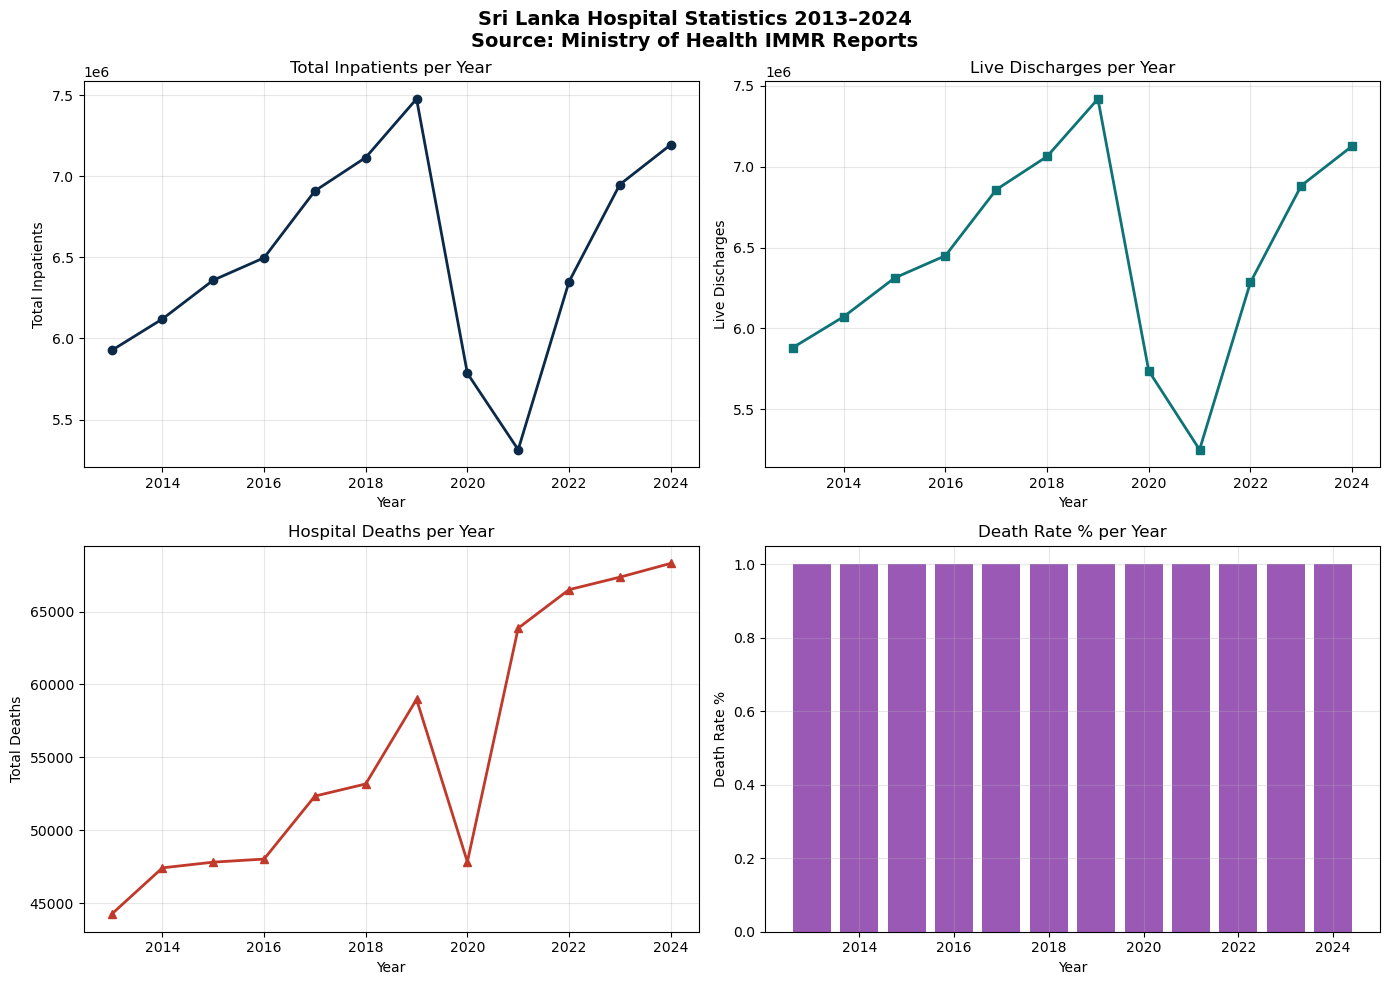

✅ Charts saved to notebooks/eda_plots.png


In [10]:
# Clean column names
df_immr.columns = df_immr.columns.str.strip()
df_immr = df_immr.dropna(subset=['Year'])
df_immr['Year'] = df_immr['Year'].astype(int)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Sri Lanka Hospital Statistics 2013–2024\nSource: Ministry of Health IMMR Reports',
             fontsize=14, fontweight='bold')

# Plot 1 — Total Inpatients
axes[0,0].plot(df_immr['Year'], df_immr['Total Inpatients'],
               marker='o', color='#0B2A4A', linewidth=2)
axes[0,0].set_title('Total Inpatients per Year')
axes[0,0].set_xlabel('Year'); axes[0,0].set_ylabel('Total Inpatients')
axes[0,0].grid(True, alpha=0.3)

# Plot 2 — Live Discharges
axes[0,1].plot(df_immr['Year'], df_immr['Disc TOTAL'],
               marker='s', color='#0D7377', linewidth=2)
axes[0,1].set_title('Live Discharges per Year')
axes[0,1].set_xlabel('Year'); axes[0,1].set_ylabel('Live Discharges')
axes[0,1].grid(True, alpha=0.3)

# Plot 3 — Deaths
axes[1,0].plot(df_immr['Year'], df_immr['Deaths TOTAL'],
               marker='^', color='#C0392B', linewidth=2)
axes[1,0].set_title('Hospital Deaths per Year')
axes[1,0].set_xlabel('Year'); axes[1,0].set_ylabel('Total Deaths')
axes[1,0].grid(True, alpha=0.3)

# Plot 4 — Death Rate
axes[1,1].bar(df_immr['Year'], df_immr['Death Rate %'],
              color='#9B59B6')
axes[1,1].set_title('Death Rate % per Year')
axes[1,1].set_xlabel('Year'); axes[1,1].set_ylabel('Death Rate %')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('notebooks/eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Charts saved to notebooks/eda_plots.png")

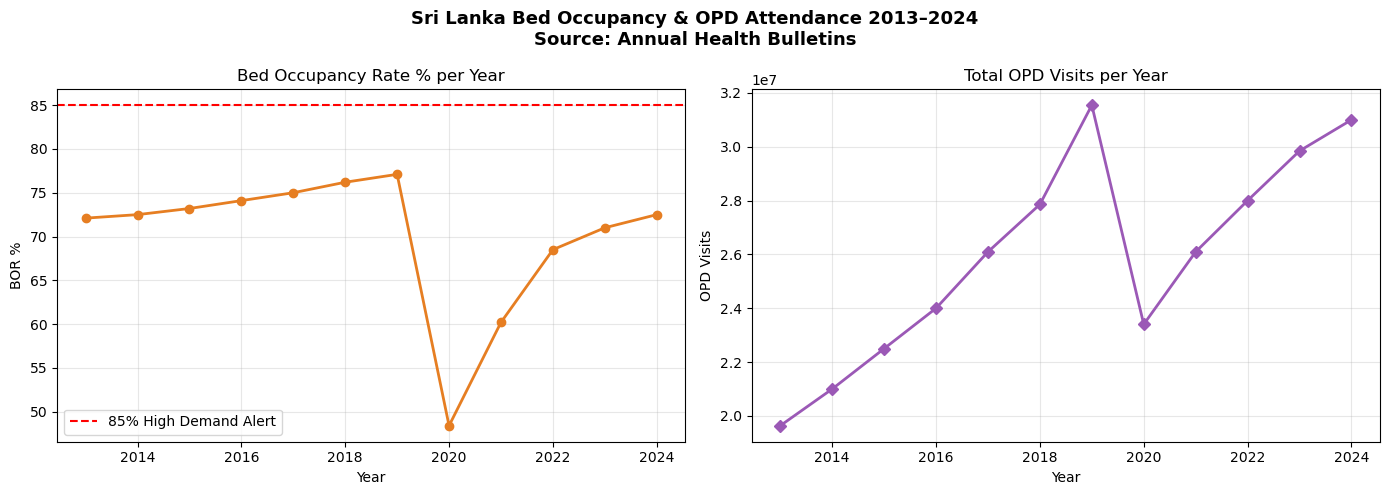

✅ Charts saved!


In [11]:
# Clean bed and OPD data
df_bed = pd.read_excel(
    'data/immr/FlowOpt_SriLanka_AHB_Data.xlsx',
    sheet_name='2_Bed_Occupancy', skiprows=1
)
df_opd = pd.read_excel(
    'data/immr/FlowOpt_SriLanka_AHB_Data.xlsx',
    sheet_name='3_OPD_Attendance', skiprows=1
)

df_bed.columns = df_bed.columns.str.strip()
df_opd.columns = df_opd.columns.str.strip()

df_bed = df_bed[pd.to_numeric(df_bed['Year'], errors='coerce').notna()]
df_opd = df_opd[pd.to_numeric(df_opd['Year'], errors='coerce').notna()]

df_bed['Year'] = df_bed['Year'].astype(int)
df_opd['Year'] = df_opd['Year'].astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Sri Lanka Bed Occupancy & OPD Attendance 2013–2024\nSource: Annual Health Bulletins',
             fontsize=13, fontweight='bold')

# Plot 1 — Bed Occupancy Rate
axes[0].plot(df_bed['Year'],
             df_bed['Bed Occupancy Rate (BOR) %'],
             marker='o', color='#E67E22', linewidth=2)
axes[0].axhline(y=85, color='red', linestyle='--',
                label='85% High Demand Alert')
axes[0].set_title('Bed Occupancy Rate % per Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('BOR %')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2 — OPD Visits
axes[1].plot(df_opd['Year'],
             df_opd['Total OPD Visits (All Hospitals)'],
             marker='D', color='#9B59B6', linewidth=2)
axes[1].set_title('Total OPD Visits per Year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('OPD Visits')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('notebooks/bed_opd_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Charts saved!")

In [12]:
print("=== DATA LOADING SUMMARY ===")
print(f"IMMR Data:  {df_immr.shape[0]} years × {df_immr.shape[1]} columns")
print(f"Bed Data:   {df_bed.shape[0]} years × {df_bed.shape[1]} columns")
print(f"OPD Data:   {df_opd.shape[0]} years × {df_opd.shape[1]} columns")
print(f"\nYears covered: {df_immr['Year'].min()} to {df_immr['Year'].max()}")
print(f"Total Inpatients 2024: {df_immr[df_immr['Year']==2024]['Total Inpatients'].values[0]:,.0f}")
print(f"Bed Occupancy 2024:    {df_bed[df_bed['Year']==2024]['Bed Occupancy Rate (BOR) %'].values[0]}%")
print(f"OPD Visits 2024:       {df_opd[df_opd['Year']==2024]['Total OPD Visits (All Hospitals)'].values[0]:,.0f}")
print("\n✅ Week 1 Day 1-2 Complete — Data Loading Done!")

=== DATA LOADING SUMMARY ===
IMMR Data:  12 years × 11 columns
Bed Data:   12 years × 6 columns
OPD Data:   12 years × 7 columns

Years covered: 2013 to 2024
Total Inpatients 2024: 7,194,899
Bed Occupancy 2024:    72.5%
OPD Visits 2024:       31,000,000

✅ Week 1 Day 1-2 Complete — Data Loading Done!
